In [1]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt 

from Vares import EVT_var, historical_var, parametric_var_normal
import Vares

In [2]:
_ = pd.read_excel('hist.xlsx').to_numpy()
prices_usd = _[:, -2]

def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = np.array(rets, dtype='float64')
    return rets 

original_returns_usd  = return_array(prices_usd)
original_returns_usd_scaled = original_returns_usd * 100

log_returns_usd = np.log(1 + original_returns_usd)
log_returns_usd_scaled = log_returns_usd * 100 

# Rolling parameters
window = 365 #calendar year 
alpha = 0.01  

rolling_mean = np.convolve(log_returns_usd_scaled, np.ones(window)/window, mode='valid')

In [3]:
Vares.ENABLE_TIMING = False

In [4]:
EVT_var(original_returns_usd_scaled[1000:1365])

Array(2.58019452, dtype=float64)

In [5]:
#simple 1 day VaR 
lag = 365 #calendar year
time_series_length = original_returns_usd.shape[0]
avialable_lenth = time_series_length - lag

historical_vars_99 = [0]*lag
parametric_vars_99 = [0]*lag
EVT_vars_99 = [0]*lag
historical_vars_95 = [0]*lag
parametric_vars_95 = [0]*lag
EVT_vars_95 = [0]*lag

for t in range(avialable_lenth): 
    returns_sliced = log_returns_usd_scaled[t:t+365]
    historical_vars_99.append(historical_var(returns_sliced, alpha=0.01))
    historical_vars_95.append(historical_var(returns_sliced, alpha=0.05))
    parametric_vars_99.append(parametric_var_normal(returns_sliced, alpha=0.01))
    parametric_vars_95.append(parametric_var_normal(returns_sliced, alpha=0.05))
    # EVT_vars_99.append(EVT_var(returns_sliced, alpha=0.01))
    # EVT_vars_95.append(EVT_var(returns_sliced, alpha=0.05))


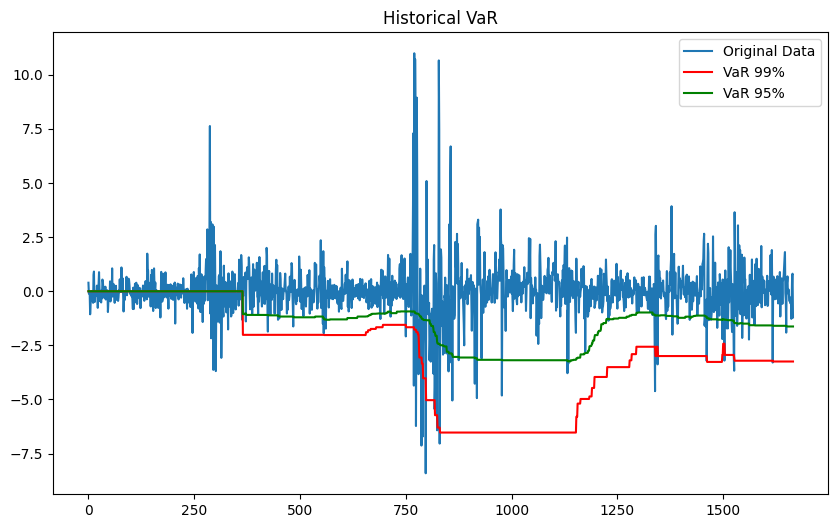

In [6]:
historical_vars_99_ = [-1 * _ for _ in historical_vars_99]
historical_vars_95_ = [-1 * _ for _ in historical_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(historical_vars_99_, color='red', label='VaR 99%')
plt.plot(historical_vars_95_, color='green', label='VaR 95%')
plt.title('Historical VaR')
plt.legend()
plt.show()


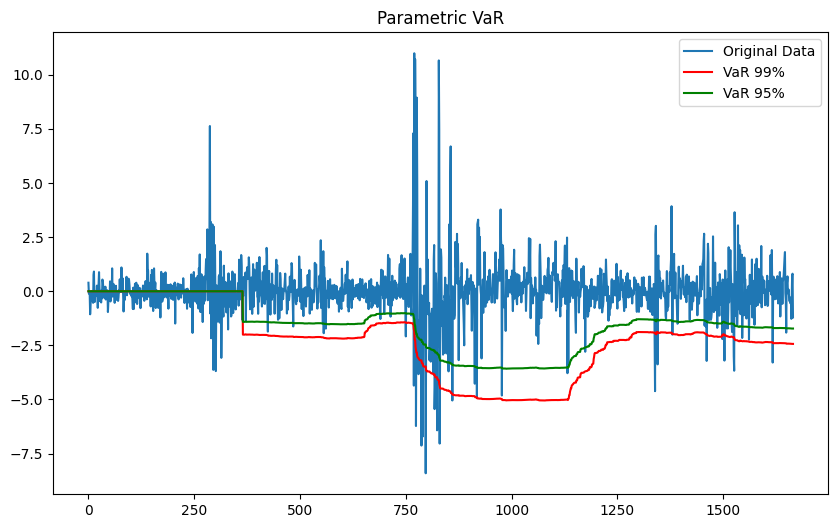

In [7]:
parametric_vars_99_ = [-1 * _ for _ in parametric_vars_99]
parametric_vars_95_ = [-1 * _ for _ in parametric_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(parametric_vars_99_, color='red', label='VaR 99%')
plt.plot(parametric_vars_95_, color='green', label='VaR 95%')
plt.title('Parametric VaR')
plt.legend()
plt.show()

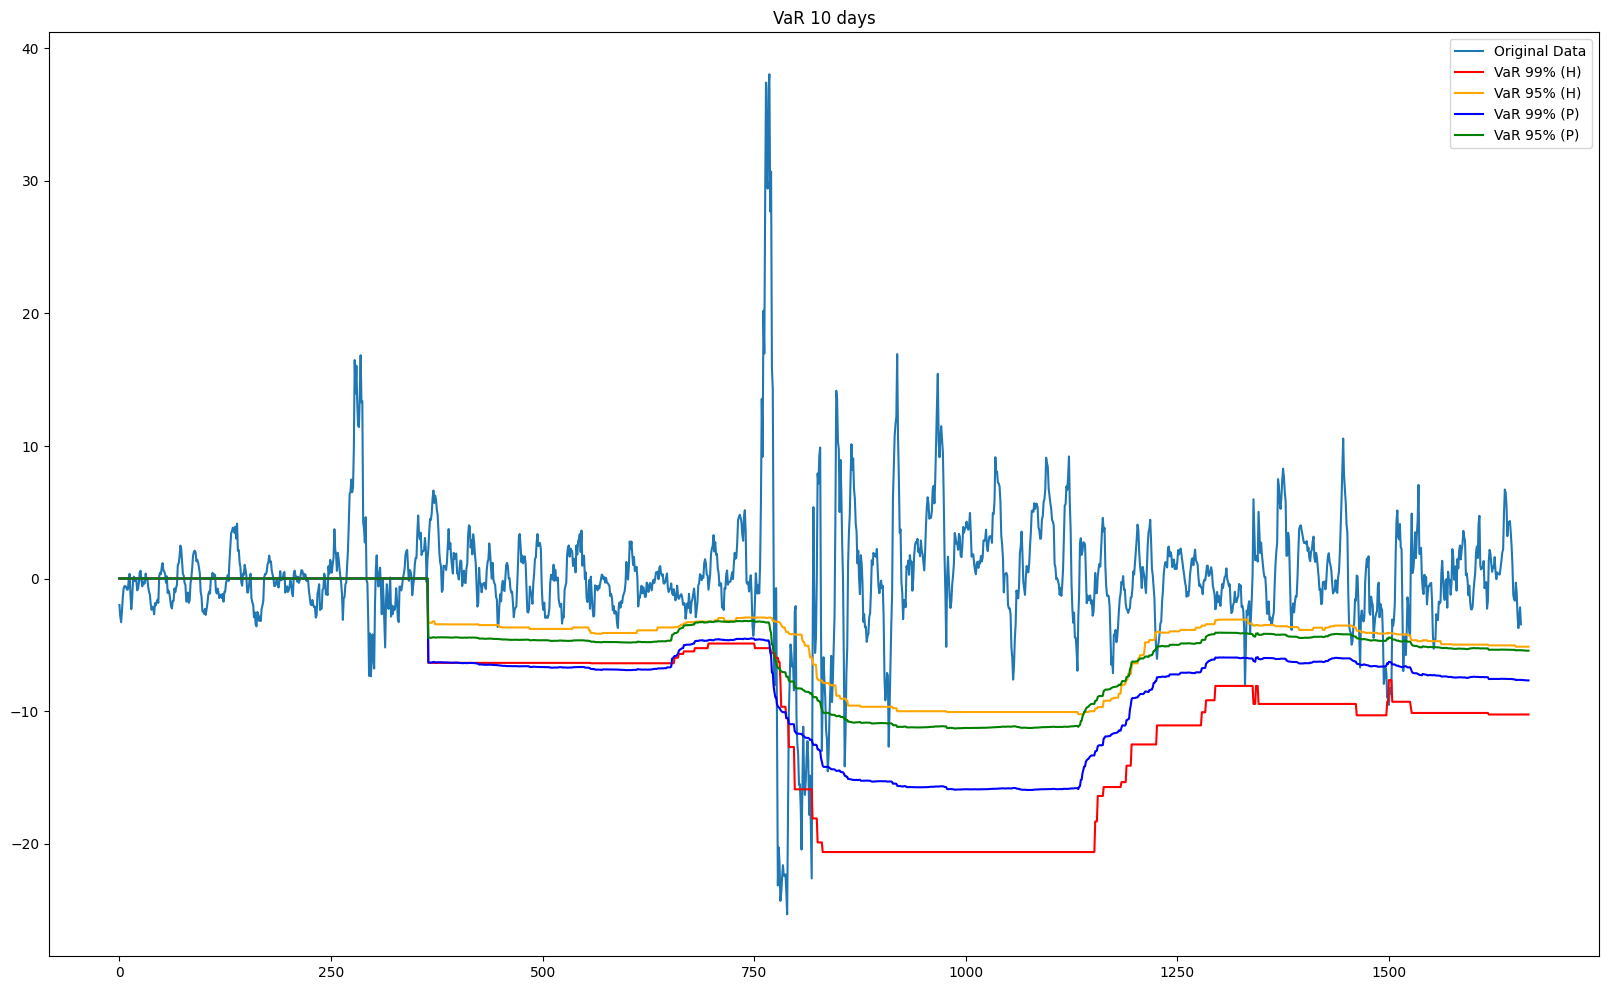

In [8]:
window = 10
cummulative_log_returns = np.convolve(log_returns_usd_scaled, np.ones(window), mode='valid')

historical_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_99]
historical_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_95]

parametric_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_99]
parametric_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original Data')
plt.plot(historical_vars_99_10, color='red', label='VaR 99% (H)')
plt.plot(historical_vars_95_10, color='orange', label='VaR 95% (H)')
plt.plot(parametric_vars_99_10, color='blue', label='VaR 99% (P)')
plt.plot(parametric_vars_95_10, color='green', label='VaR 95% (P)')
plt.title('VaR 10 days')
plt.legend()
plt.show()


GARCH's

In [9]:
import sys 

import Vares_simulations    

if Vares_simulations in sys.modules: 
    del sys.modules[Vares_simulations]

from Vares_simulations import *
from Vares_simulations import _terminal_returns

In [ ]:
p_usd = ProtoPortfolio(log_returns_usd_scaled) 
p_usd.calibrate(horizon=10)
params_usd = SimParams(p_usd.parameters.volatility, p_usd.parameters.mean)

simulator_usd_norm = make_random_path_simulator_local_vol(params_usd, 10, dist='norm')
returns_usd_sim_norm = _terminal_returns(simulator_usd_norm, 50000)
simulator_usd_t = make_random_path_simulator_local_vol(params_usd, 10, df=3, scale=0.55)
returns_usd_sim_t = _terminal_returns(simulator_usd_t, 50000)

c:\Users\alexa\OneDrive\Desktop\python\domrg\Vares_simulations.py:299: RuntimeWarning: overflow encountered in exp
  cum_returns = np.exp(cum_log_returns) - 1
